In [3]:
import map_fun as mf
import matplotlib.pyplot as plt
import numpy as np
import models

mapmeta = mf.load_h5("mapmeta.h5")
maps = [mf.obsmap(meta) for key, meta in mapmeta.items() if meta['valid_data']]

fitmeta = mf.load_h5("fits/EllipticGaussian.h5")
[map2use.load_fit(models.EllipticGaussian, fitmeta) for map2use in maps];

In [5]:
query = mf.query_maps(mapmeta, 
    tube_slot="lati1",
    wafer="ufm_mv21",
    band="f090",
    epoch='ep4')

selection = [map2use for map2use in maps if map2use.meta_name in query]
map2use = selection[0]
T, Q, U = map2use.solved

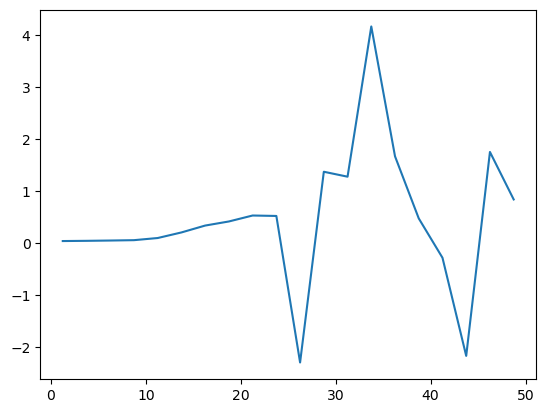

In [28]:
P = np.sqrt(Q**2+U**2)
muy, mux = map2use.EllipticGaussian.muy[0],map2use.EllipticGaussian.mux[0]
X,Y = mf.radial_profile(P/T, center=(muy,mux), nbins=int(50//2.4), rmax=50)
plt.plot(X,Y)
plt.show()

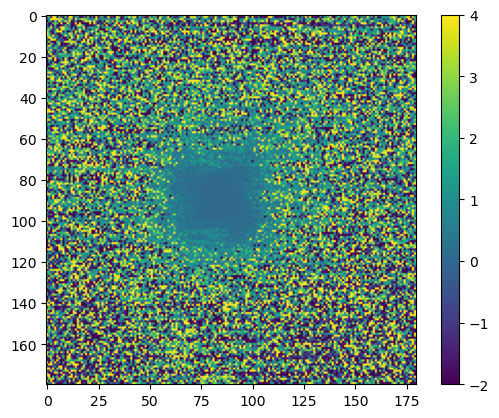

In [31]:
plt.imshow(P/T, vmin=-2, vmax=4)
plt.colorbar()
plt.show()

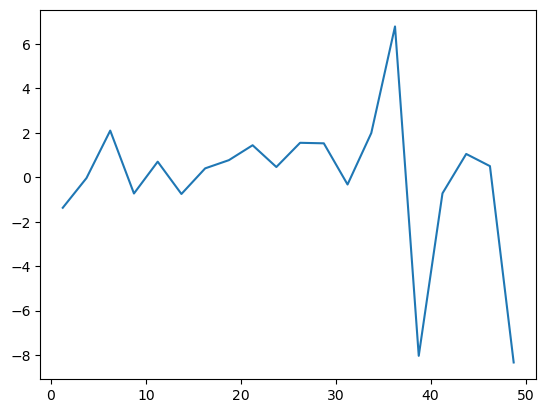

In [32]:
coords = mf.get_coords(T)
popt = map2use.EllipticGaussian.get_popt()
fit = models.EllipticGaussian().func(coords, *popt).reshape((180,180))
T_ = T - fit
P = np.sqrt(Q**2+U**2)
muy, mux = map2use.EllipticGaussian.muy[0],map2use.EllipticGaussian.mux[0]
X,Y = mf.radial_profile(P/T_, center=(90,90), nbins=int(50//2.4), rmax=50)
plt.plot(X,Y)
plt.show()

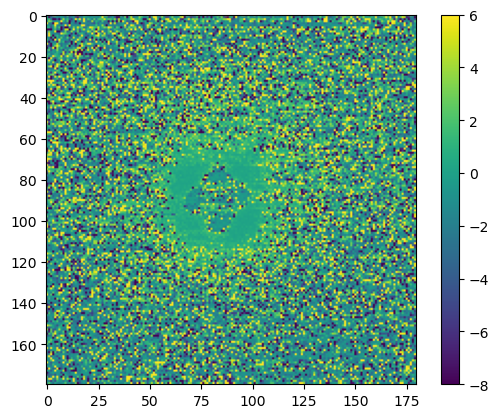

In [33]:
plt.imshow(P/T_, vmin=-8, vmax=6)
plt.colorbar()
plt.show()